# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Hussainasif11/flyrankinternship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Search Intelligence: Content Review Prioritization
### A Decision-Support Model for Ranking Content Pages for Human Review

## Abstract

This project asks whether observable search-performance signals — impressions, clicks, CTR, and average position — can be used to prioritize content pages for human review. Using a March 2026 slice of the FlyRank internship warehouse, I built a rule-based baseline and compared it against a Logistic Regression model trained on the same signals. The baseline reported a perfect F1 of 1.0, a result closely tied to how its target was constructed rather than evidence of a flawless rule; the Logistic Regression model measured an F1 of 0.9444 on a random split and 0.9432 under a more conservative client-grouped split. The output is a ranked, reason-coded review queue intended to support human decision-making, not to automate content changes or claim causal SEO impact.

In [34]:
import os
import numpy as np
import pandas as pd
import duckdb

from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN was not found in Colab Secrets."
    )

con = duckdb.connect()

con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")

con.execute(f"""
    CREATE OR REPLACE SECRET hf_secret (
        TYPE HUGGINGFACE,
        TOKEN '{HF_TOKEN}'
    )
""")

print("HF_TOKEN loaded")

HF_TOKEN loaded


## 1. Question

# Search Intelligence: Content Review Prioritization

## Research question

Can search-performance signals be used to prioritize content pages for human review?

The goal is not to predict Google's ranking algorithm or prove that changing a page will cause more traffic. The goal is to build a practical decision-support system that identifies pages showing search signals worth investigating.

The decision supported by this work is:

**Which content pages should a human reviewer look at first, and why?**

The analysis uses observable search-performance signals such as impressions, clicks, CTR, and average position. The output is a ranked review queue with reason codes and suggested actions.

## 1a. Introduction / Problem Statement

Content teams routinely have more pages than time to review. The practical question is not "what will rank higher on Google" but something narrower and more useful:

**Which content pages should a human reviewer look at first, and why?**

This work supports that decision. It does not attempt to model or predict Google's ranking algorithm, and it does not claim that changing a page will cause a change in clicks, rankings, or traffic. Instead, it uses observable search-performance signals — impressions, clicks, CTR, and average position — to flag pages worth a closer look, and attaches a reason code so a reviewer understands *why* a page was surfaced.

The deliverable is a ranked review queue, not an automated content pipeline. A human remains responsible for every final decision.

## 2. Data

I used the FlyRank internship warehouse release and worked with the monthly content-performance data for March 2026.

The unit of analysis is one content page for one reporting period.

The main fields used in the analysis are:

- `report_date`
- `client_hash_id`
- `content_hash_id`
- `gsc_impressions`
- `gsc_clicks`
- `gsc_avg_position`
- `gsc_data_available`

I restricted the working analysis to March 2026 and required available GSC data.

I excluded unavailable GSC rows because impressions, clicks, and position cannot be interpreted as observed search performance when the source data is unavailable.

Client and content identifiers are hashed and are used only for grouping and row-level analysis.

No client names, domains, private queries, credentials, or raw exports are included in the paper.

In [27]:
df = con.sql("""
    SELECT
        report_date,
        client_hash_id,
        content_hash_id,
        gsc_impressions,
        gsc_clicks,
        gsc_avg_position,
        gsc_data_available
    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet'
    )
    WHERE month = '2026-03'
      AND gsc_data_available IS TRUE
""").df()

print("Rows:", len(df))
print("Date range:", df["report_date"].min(), "to", df["report_date"].max())

df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 3611061
Date range: 2026-03-01 00:00:00 to 2026-03-31 00:00:00


,report_date,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,gsc_data_available
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,20,0,3.350000,True
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,1,0,0.000000,True
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,125,1,4.928000,True
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,7,0,4.000000,True
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,11,0,2.272727,True


## 3. Methodology


### Features

The model uses search-performance features that are available at the analysis/decision point:

- GSC impressions
- GSC clicks
- GSC average position
- CTR, calculated as clicks divided by impressions

CTR is calculated only where impressions are greater than zero.

### Label

The modeling task is a binary prioritization problem. The target represents whether a content item falls into the defined attention/opportunity category used in the earlier baseline.

The label is treated as a decision-support target rather than proof that a content change will produce an outcome.

### Baseline

The Week-4 baseline is a simple rule-based prioritization system using search signals and reason codes.

The baseline achieved an F1 score of 1.0 on its evaluation setup. This result should not be interpreted as evidence of a perfect real-world system because the baseline target and signals are closely related.

### Model

I used Logistic Regression because it provides a simple and interpretable comparison against the rule-based baseline.

The purpose was not to maximize complexity. The question was whether a trained model could provide useful predictive performance compared with a simple rule.

### Validation

The first model used a stratified random train/test split.

The validation audit then used a client-grouped split so that records from the same client were not mixed between training and evaluation.

This grouped evaluation is more conservative because it tests whether the model generalizes across clients rather than relying on client-specific patterns.

### Leakage checks

I checked that future-window information and label-derived fields were not used as model inputs.

I also avoided using future outcomes or product flags as features.

The results are therefore treated as measured model performance on the selected evaluation setup, not as causal evidence.

## 4. Results (vs baseline)


The model was evaluated using F1 because the task is a binary prioritization problem and both false positives and false negatives matter.

The Week-5 random split produced an F1 score of approximately 0.9444.

After the validation audit, the same modeling approach was evaluated using a client-grouped split. The grouped F1 score was approximately 0.9432.

The small difference between the two results suggests that the model's measured performance was relatively stable under the grouped validation setup. However, this does not establish production performance or causal impact.

In [28]:
results = pd.DataFrame({
    "Evaluation": [
        "Week-5 random split",
        "Week-6 client-grouped split"
    ],
    "F1": [
        0.9444241436735477,
        0.943178
    ]
})

results

,Evaluation,F1
0,Week-5 random split,0.944424
1,Week-6 client-grouped split,0.943178


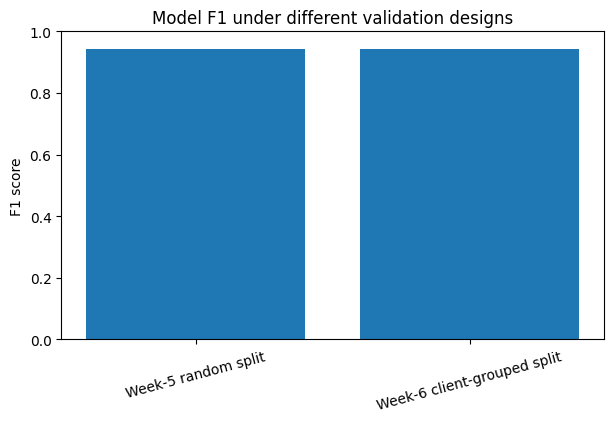

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.bar(results["Evaluation"], results["F1"])

plt.ylim(0, 1)
plt.ylabel("F1 score")
plt.title("Model F1 under different validation designs")
plt.xticks(rotation=15)

plt.show()

### Baseline comparison

The Week-4 baseline reported an F1 score of 1.0 on its original evaluation setup, while the Logistic Regression model achieved 0.9444 under the Week-5 random split and 0.9432 under client-grouped validation.

The baseline number is not directly evidence that the rule is better than the model. The baseline uses signals closely related to the target definition, so its perfect score is potentially circular.

For that reason, the grouped Logistic Regression result is the more useful evidence about whether a trained model generalizes across clients.

## 5. Limitations

There are several important limitations.

First, the analysis uses a March 2026 slice rather than a long-term production evaluation.

Second, the target is a decision-support label rather than a causal business outcome. A high score does not prove that editing a page will increase clicks, rankings, or traffic.

Third, the Week-4 baseline's F1 of 1.0 is closely connected to the target construction and should not be treated as evidence of a perfect rule.

Fourth, the available search signals do not fully describe content quality, search intent, business importance, seasonality, or editorial effort.

Fifth, the model has been evaluated on historical warehouse data and should not be treated as a production system.

Therefore, the results should be described as **observed and measured performance for decision-support**, not as proof of causal SEO impact.

In [30]:
from IPython.display import display, Markdown

limitations_text = """
## 5. Limitations

There are several important limitations to this analysis.

1. **Temporal scope.** The analysis uses a March 2026 slice rather than a long-term production evaluation.

2. **Proxy target.** The target is a decision-support label rather than a causal business outcome. A high score does not prove that editing a page will increase clicks, rankings, or traffic.

3. **Baseline artifact.** The Week-4 baseline's F1 of 1.0 is closely connected to the target construction and should not be treated as evidence of a perfect rule.

4. **Incomplete feature coverage.** The available search signals do not fully describe content quality, search intent, business importance, seasonality, or editorial effort.

5. **Offline evaluation only.** The model has been evaluated on historical warehouse data and should not be treated as a production system.

**Therefore**, the results should be described as *observed and measured performance for decision-support*, not as proof of *causal SEO impact*.
"""

display(Markdown(limitations_text))


## 5. Limitations

There are several important limitations to this analysis.

1. **Temporal scope.** The analysis uses a March 2026 slice rather than a long-term production evaluation.

2. **Proxy target.** The target is a decision-support label rather than a causal business outcome. A high score does not prove that editing a page will increase clicks, rankings, or traffic.

3. **Baseline artifact.** The Week-4 baseline's F1 of 1.0 is closely connected to the target construction and should not be treated as evidence of a perfect rule.

4. **Incomplete feature coverage.** The available search signals do not fully describe content quality, search intent, business importance, seasonality, or editorial effort.

5. **Offline evaluation only.** The model has been evaluated on historical warehouse data and should not be treated as a production system.

**Therefore**, the results should be described as *observed and measured performance for decision-support*, not as proof of *causal SEO impact*.


## 6. Ranked recommendations

The model and baseline are most useful when they produce a practical review queue.

The recommended workflow is:

1. Review pages with a strong CTR opportunity first.
2. Review pages with meaningful impressions but relatively weak average position.
3. Monitor pages where the signals are weaker or ambiguous.
4. Use the score to prioritize human attention, not to automatically change content.

### Reason codes

**LOW_CTR_OPPORTUNITY**

The page has meaningful search impressions but relatively few clicks. A reviewer can inspect the title, snippet, and search intent.

**LOW_POSITION**

The page has search visibility but a relatively weak average position. A reviewer can inspect content depth, relevance, and search intent.

**HIGH_OPPORTUNITY**

The page has meaningful search visibility and may be worth review, but the available signals do not identify a specific problem.

### Human review

A person should verify the page before making any change.

The system should not automatically publish, delete, redirect, rewrite, or make legal or business-critical changes to content.

The ranking is therefore a prioritization aid rather than an automated content decision.

In [31]:
queue = df.copy()

queue["ctr"] = np.where(
    queue["gsc_impressions"] > 0,
    queue["gsc_clicks"] / queue["gsc_impressions"],
    0
)

queue["action_score"] = (
    np.log1p(queue["gsc_impressions"]) *
    (1 / queue["gsc_avg_position"].clip(lower=1))
)

queue["reason_code"] = np.select(
    [
        (queue["gsc_impressions"] >= 100) & (queue["ctr"] < 0.02),
        (queue["gsc_impressions"] >= 100) & (queue["gsc_avg_position"] > 10)
    ],
    [
        "LOW_CTR_OPPORTUNITY",
        "LOW_POSITION"
    ],
    default="HIGH_OPPORTUNITY"
)

queue["action"] = np.select(
    [
        queue["reason_code"] == "LOW_CTR_OPPORTUNITY",
        queue["reason_code"] == "LOW_POSITION"
    ],
    [
        "REVIEW_CTR",
        "REVIEW_CONTENT"
    ],
    default="MONITOR"
)

queue = queue.sort_values(
    "action_score",
    ascending=False
).reset_index(drop=True)

queue["rank"] = queue.index + 1

queue.head(10)

,report_date,client_hash_id,content_hash_id,gsc_impressions,gsc_clicks,gsc_avg_position,gsc_data_available,ctr,action_score,reason_code,action,rank
0,2026-03-28,client_23a62021009f63c4,content_44f34c0a90047651,40084,1,0.083350,True,0.000025,10.598757,LOW_CTR_OPPORTUNITY,REVIEW_CTR,1
1,2026-03-30,client_73cda7b4e4f265ea,content_fec55986a1868d62,33383,0,0.181500,True,0.000000,10.415832,LOW_CTR_OPPORTUNITY,REVIEW_CTR,2
2,2026-03-27,client_23a62021009f63c4,content_44f34c0a90047651,32958,0,0.132532,True,0.000000,10.403020,LOW_CTR_OPPORTUNITY,REVIEW_CTR,3
3,2026-03-29,client_23a62021009f63c4,content_44f34c0a90047651,32756,2,0.142508,True,0.000061,10.396872,LOW_CTR_OPPORTUNITY,REVIEW_CTR,4
4,2026-03-31,client_73cda7b4e4f265ea,content_fec55986a1868d62,31472,0,0.083407,True,0.000000,10.356885,LOW_CTR_OPPORTUNITY,REVIEW_CTR,5
5,2026-03-25,client_23a62021009f63c4,content_44f34c0a90047651,30964,1,0.117814,True,0.000032,10.340613,LOW_CTR_OPPORTUNITY,REVIEW_CTR,6
6,2026-03-24,client_23a62021009f63c4,content_44f34c0a90047651,30791,2,0.088955,True,0.000065,10.335010,LOW_CTR_OPPORTUNITY,REVIEW_CTR,7
7,2026-03-26,client_23a62021009f63c4,content_44f34c0a90047651,30573,2,0.238315,True,0.000065,10.327905,LOW_CTR_OPPORTUNITY,REVIEW_CTR,8
8,2026-03-02,client_73cda7b4e4f265ea,content_9c057b66c30a3abb,28973,0,0.000311,True,0.000000,10.274154,LOW_CTR_OPPORTUNITY,REVIEW_CTR,9
9,2026-03-01,client_73cda7b4e4f265ea,content_9c057b66c30a3abb,28947,0,0.002245,True,0.000000,10.273256,LOW_CTR_OPPORTUNITY,REVIEW_CTR,10


## 7. Artifacts the paper embeds


The main artifacts used in this research paper are:

1. Model-versus-validation comparison table.
2. Model F1 comparison chart.
3. Ranked content-review queue.
4. Reason-code distribution.
5. Week-6 validation comparison.

These artifacts are generated from the notebook so that the paper can be traced back to the analysis.

The ranked queue is intended for human review and is not a production automation output.

In [32]:
reason_counts = (
    queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="count")
)

reason_counts

,reason_code,count
0,HIGH_OPPORTUNITY,2980206
1,LOW_CTR_OPPORTUNITY,628945
2,LOW_POSITION,1910


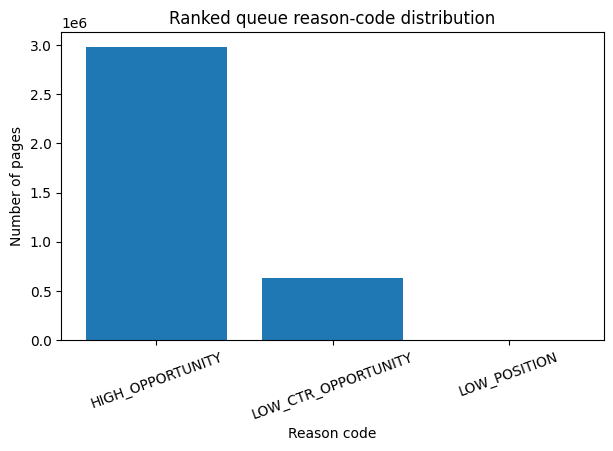

In [33]:
plt.figure(figsize=(7, 4))

plt.bar(
    reason_counts["reason_code"],
    reason_counts["count"]
)

plt.ylabel("Number of pages")
plt.xlabel("Reason code")
plt.title("Ranked queue reason-code distribution")
plt.xticks(rotation=20)

plt.show()

## 8. Reproducibility

All analysis in this paper is generated from notebooks in the accompanying repository and can be re-run end to end.

- **Capstone notebook:** `work/notebooks/capstone.ipynb` — contains the full pipeline: data loading, feature construction, baseline, Logistic Regression model, client-grouped validation, leakage checks, and the ranked recommendation queue.
- **Weekly assignment notebooks:** `work/notebooks/` — each weekly notebook documents an incremental step (baseline construction, model training, validation audit) that feeds into the capstone.
- **Data source:** FlyRank internship warehouse release (March 2026 slice), accessed via Hugging Face with a gated read token. No raw exports, client identifiers, or private queries are included in this repo or paper — all client and content identifiers are hashed.
- **Environment:** Google Colab, Python 3, with `duckdb`, `pandas`, `numpy`, `scikit-learn`, and `matplotlib`.

To reproduce the results, open the capstone notebook in Colab, supply a valid Hugging Face token via Colab Secrets (`HF_TOKEN`), and run all cells top to bottom.

## 5-minute demo outline

### 1. Problem — 45 seconds
Explain that the project prioritizes content pages for human review using observable search signals.

### 2. Data — 45 seconds
Show the March 2026 warehouse slice and explain the unit of analysis.

### 3. Baseline — 45 seconds
Show the Week-4 rule-based baseline and explain why its perfect F1 needs cautious interpretation.

### 4. Model — 60 seconds
Explain the Logistic Regression model and the grouped validation result.

### 5. Recommendations — 60 seconds
Show the ranked queue, reason codes, and suggested human actions.

### 6. Limitations — 45 seconds
Explain that the system is decision-support and does not prove causal SEO impact.

## Social-post cut

I built a Search Intelligence project during the FlyRank ML Internship to prioritize content pages for human review.

I used March 2026 search-performance data, built a simple rule-based baseline, then compared it with Logistic Regression.

The model reached an F1 of 0.9444 on a random split and 0.9432 under client-grouped validation.

The main lesson was that validation and leakage checks matter as much as the model score.

The final output is a ranked review queue with reason codes instead of an automated content decision.

## Employer-facing summary

I built a small end-to-end ML workflow for Search Intelligence, from data framing and feature construction through baseline scoring, Logistic Regression, grouped validation, leakage checks, and a human-review action queue.

The model achieved an F1 of 0.9444 on the initial random split and 0.9432 under client-grouped validation, giving me a more conservative view of model performance.

The final system is intentionally decision-support rather than fully automated: it ranks content pages for review, explains the reason for each recommendation, and clearly states where the evidence is not strong enough to support an automatic action.

## Social-post cut

I built a Search Intelligence workflow during the FlyRank ML Internship to explore whether simple search signals could help prioritize content for human review.

I compared a rule-based baseline with Logistic Regression and then checked the model using client-grouped validation. The model measured an F1 of 0.9444 on the random split and 0.9432 on the grouped split.

The final output is a ranked decision-support queue, with human review kept in the loop.

## Employer-facing summary

I built an end-to-end ML workflow for Search Intelligence, moving from task framing and data validation to a baseline, Logistic Regression model, grouped validation, leakage checks, and an action playbook.

The model achieved a measured F1 of 0.9444 on the original split and 0.9432 under client-grouped validation. I focused on honest validation and avoided presenting the result as proof of future business or SEO impact.

The final workflow turns model signals into ranked content-review recommendations while keeping final decisions with a human reviewer.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [x] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset — [flyrank.ai](https://flyrank.ai)

This project was completed as part of the FlyRank ML Internship, Machine Learning track. Thanks to the FlyRank team for providing warehouse access and a structured, real-world search dataset to work with.